# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)

**Notebook de la Clase 2** (validación formal + árboles de decisión), copia de `tp_spotify_clase1_knn.ipynb` con el contenido de la Clase 1 intacto (EDA, feature engineering, baseline KNN) más la sección nueva de la Clase 2 al final. Cada clase queda en su propio archivo como registro de estudio; el consolidado final para la entrega se arma más adelante, cerca de la fecha límite.

## Base heredada de la Clase 1 (mínima)

Cada clase vive en su propio notebook. El razonamiento completo (EDA con 2 figuras, comparación de tres conjuntos de features, barrido fino de K, chequeo temporal) queda en `tp_spotify_clase1_knn.ipynb` — no se repite acá, solo se usa el resultado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "competition_data"

# Estilo único para todos los gráficos del notebook.
# Paleta categórica validada para daltonismo (orden fijo: azul, aqua, amarillo).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode",
    "user_id",  # excluida en la Clase 1 como "identificador"; decisión revisada en la sección final de este notebook
]
DTYPES = {
    "spotify_track_uri": "string",
    "spotify_episode_uri": "string",
    "audiobook_uri": "string",
}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES)

train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

print("Filas:", len(train_raw))
print("Proporción de abandono temprano (target=1):", train_raw["target"].mean().round(4))
train_raw[["obs_id", "ms_played", "target"]].head()

Filas: 911344
Proporción de abandono temprano (target=1): 0.278


,obs_id,ms_played,target
0,1,8956,1
1,2,202024,0
2,3,269480,0
3,4,24299,1
4,5,97877,0


In [3]:
# Mismas tres derivadas de la Clase 1 (justificación completa en esa clase, acá solo el resultado):
# content_type (qué URI está presente), hora/dia_semana (de ts, en UTC), artista_top (top 50 de train, resto -> "otros").

train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)

ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(
    train_raw[col_artista].isin(TOP_ARTISTAS), "otros"
)

print("Features derivadas listas. artista_top:", train_raw["artista_top"].nunique(), "categorías (incluye 'otros').")

Features derivadas listas. artista_top: 51 categorías (incluye 'otros').


In [4]:
# La Clase 1 comparó 3 conjuntos anidados con el mismo holdout y grilla de K; ganó el conjunto C
# (todas las variables: contexto + momento + contenido), con AUC holdout aleatorio 0.6903 (K=101)
# que bajaba a 0.6477 al respetar el tiempo. Partimos directo de ese resultado ya validado.
TODAS_LAS_FEATURES = [
    "platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
    "hora", "dia_semana", "content_type", "artista_top",
]
mejor_feats = TODAS_LAS_FEATURES

## Clase 2 — Validación formal (train/validation/test) y Árboles de Decisión

Todo lo de arriba es la base mínima heredada de la Clase 1 (`train_raw` con target y features derivadas, `TODAS_LAS_FEATURES`/`mejor_feats` = conjunto C ya validado). De acá en adelante es contenido nuevo de la Clase 2:

1. Un **esquema de validación formal train / validation / test**, que reemplaza el holdout único (y el "chequeo de honestidad" improvisado) de la Clase 1.
2. **Árboles de decisión** como segundo algoritmo, diseñados con lo visto en clase y comparados de forma honesta contra un campeón de KNN.

### Por qué ahora tres conjuntos y no dos

En la Clase 1 alcanzaba con un único holdout: entrenar, mirar cómo da afuera, listo — una sola decisión (el K) apoyada en un solo número. De acá en adelante vamos a tomar *muchas* decisiones: qué profundidad de árbol, qué mínimo de observaciones por hoja, y encima comparar dos familias de algoritmos distintas (árbol vs. KNN). La clase lo nombró con precisión — **"overfitting the validation set"** (Andrew Ng): si mirás el mismo conjunto de validación una y otra vez mientras probás combinaciones, tarde o temprano alguna le pega de casualidad al ruido de ese conjunto en particular, y el número que te queda está inflado. Cuantas más cosas probás, más grande el sesgo.

La solución que da la clase es partir en **tres**:

- **`train`**: para ajustar cada modelo candidato.
- **`validation`**: para comparar candidatos y elegir hiperparámetros. Es el número que miramos todo el tiempo, así que puede terminar "contaminado" de tanto mirarlo.
- **`test` interno**: no se toca hasta el final, una única vez, ya con los modelos elegidos — para tener una estimación honesta. Cumple el mismo rol que el leaderboard público de Kaggle, pero nos deja chequear *antes* de gastar uno de los 3 submits diarios.

Dos decisiones más, siguiendo la clase al pie de la letra:

- **Nada de K-Fold.** El profesor fue explícito: con datasets de "varios cientos de miles" de filas —nuestro caso exacto— el K-Fold es "un exceso"; alcanza con un holdout simple, y agregarlo solo suma cómputo sin mejorar la estimación. K-Fold rinde con datasets medianos (miles a decenas de miles de filas), no con el nuestro.
- **Split cronológico, no aleatorio.** Nuestras observaciones no son i.i.d.: el profesor fue explícito en que el TP "tiene un componente temporal" (los gustos musicales cambian). Igual que en el chequeo de honestidad de la Clase 1, ordenamos por fecha y cortamos — nunca mezclamos épocas entre los tres conjuntos.

Un cambio de escala respecto de la Clase 1: como los árboles no tienen el problema de costo de KNN (predecir no requiere comparar contra todo el training set), esta vez armamos el split sobre **el dataset completo** (911.344 filas) en lugar de una muestra.

In [5]:
train_raw_ord = train_raw.sort_values("ts_dt").reset_index(drop=True)

n = len(train_raw_ord)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
# el ~15% restante es el test interno

df_train = train_raw_ord.iloc[:n_train]
df_val = train_raw_ord.iloc[n_train:n_train + n_val]
df_test_interno = train_raw_ord.iloc[n_train + n_val:]

def build_xy(df, features=None):
    features = TODAS_LAS_FEATURES if features is None else features
    X = df[features].fillna("missing").astype(str)
    y = df["target"]
    return X, y

X_tr, y_tr = build_xy(df_train)
X_val, y_val = build_xy(df_val)
X_te, y_te = build_xy(df_test_interno)

for nombre, df in [("train", df_train), ("validation", df_val), ("test interno", df_test_interno)]:
    print(f"{nombre:<13} {len(df):>7} filas | {df['ts_dt'].min().date()} -> {df['ts_dt'].max().date()} "
          f"| tasa abandono {df['target'].mean():.4f}")

train          637940 filas | 2013-10-29 -> 2022-01-14 | tasa abandono 0.2864
validation     136701 filas | 2022-01-14 -> 2023-05-26 | tasa abandono 0.2870
test interno   136703 filas | 2023-05-26 -> 2024-08-31 | tasa abandono 0.2298


**Dos observaciones honestas sobre estos números:**

- `test_interno` termina el **2024-08-31**, exactamente donde termina `train_data.txt` según la consigna (train real: hasta esa fecha; test real de Kaggle: desde el 2024-09-01). No es casualidad — es la porción más reciente de nuestros datos, la más parecida en el tiempo al test real, así que es el mejor proxy interno que podemos construir.
- La tasa de abandono en `test_interno` (≈0.230) es notablemente más baja que en `train`/`validation` (≈0.286-0.287). Esto es exactamente el tipo de cosa que un split aleatorio (i.i.d.) escondería mezclando épocas, y que un split cronológico deja a la vista: el comportamiento de escucha cambió con el tiempo. Es una razón más para desconfiar de un holdout aleatorio en este problema, tal como advirtió la clase.

### Árbol de decisión: por qué el pipeline es más simple que el de KNN

Un árbol parte el espacio de atributos con cortes del tipo "¿esta variable es mayor o menor a tanto?", anidados desde la raíz hacia las hojas. En clasificación, cada hoja predice la **proporción de cada clase** entre las observaciones de entrenamiento que caen ahí — directamente una probabilidad, que es lo que necesitamos para ROC-AUC.

Dos diferencias con el pipeline de KNN de la Clase 1:

1. **Sin `StandardScaler`.** KNN necesitaba escalar porque la distancia euclídea se deja dominar por la variable de mayor varianza. Un árbol no calcula distancias: cada corte es un umbral sobre una única variable a la vez, y ese umbral separa las mismas observaciones esté la variable en la escala que esté. Escalar no cambia ni un solo corte que el árbol pueda elegir.
2. **Sigue haciendo falta `OneHotEncoder`.** La clase mostró que un árbol *podría*, en teoría, partir directo por variable categórica (una rama por categoría) — pero scikit-learn no lo tiene implementado así. Seguimos con one-hot, que la propia clase aclaró que "no es tan dramático" (ni siquiera XGBoost lo tuvo durante años y aun así competía bien).

Y a diferencia de KNN (*lazy*: todo el costo está en `.predict()`), un árbol es ***eager***: todo el costo de cómputo está en `.fit()` (construir el árbol); predecir es solo recorrer ifs, casi gratis. Por eso ahora entrenamos con **todas** las filas de `train` (~638.000), sin subsamplear — el motivo por el que subsampleábamos en la Clase 1 era exclusivo de KNN.

In [6]:
from sklearn.tree import DecisionTreeClassifier

def build_tree_pipeline(features, **tree_kwargs):
    preprocessor = ColumnTransformer(
        transformers=[
            ("onehot", OneHotEncoder(handle_unknown="ignore"), features),
        ],
        remainder="drop",
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE, **tree_kwargs)),
        ]
    )

### Eligiendo la profundidad y el mínimo de observaciones por hoja, con `validation`

Dos hiperparámetros que controlan la flexibilidad del árbol, tal como los presentó la clase:

- **`max_depth`**: cuántos niveles de cortes puede tener el árbol. Profundidad chica → underfitting (no separa lo suficiente); profundidad muy grande → overfitting (memoriza ruido del training, en el límite una hoja por observación).
- **`min_samples_leaf`**: un corte candidato solo se acepta si deja al menos esta cantidad de observaciones a cada lado. Es un freno adicional, sobre todo cuando `max_depth` es alto.

(Dejamos `min_samples_split` en el default de scikit-learn para no explotar la grilla — la clase también tuneó pocos hiperparámetros a la vez por la misma razón de cómputo.)

No hay ninguna fórmula que diga de antemano el mejor valor — el profesor fue textual: *"nunca hay regla de dedo, la regla es probar"*. Así que barremos una grilla de `max_depth` para varios valores de `min_samples_leaf`, entrenamos siempre con `train` y medimos ROC-AUC en `validation` — `test_interno` todavía no se toca.

min_samples_leaf=1    | depth=2: 0.6294 | depth=4: 0.6675 | depth=6: 0.6643 | depth=8: 0.6572 | depth=10: 0.6541 | depth=14: 0.6654 | depth=20: 0.6594 | depth=30: 0.6484
min_samples_leaf=20   | depth=2: 0.6294 | depth=4: 0.6675 | depth=6: 0.6647 | depth=8: 0.6582 | depth=10: 0.6556 | depth=14: 0.6674 | depth=20: 0.6642 | depth=30: 0.6609
min_samples_leaf=100  | depth=2: 0.6294 | depth=4: 0.6676 | depth=6: 0.6658 | depth=8: 0.6594 | depth=10: 0.6571 | depth=14: 0.6690 | depth=20: 0.6634 | depth=30: 0.6632


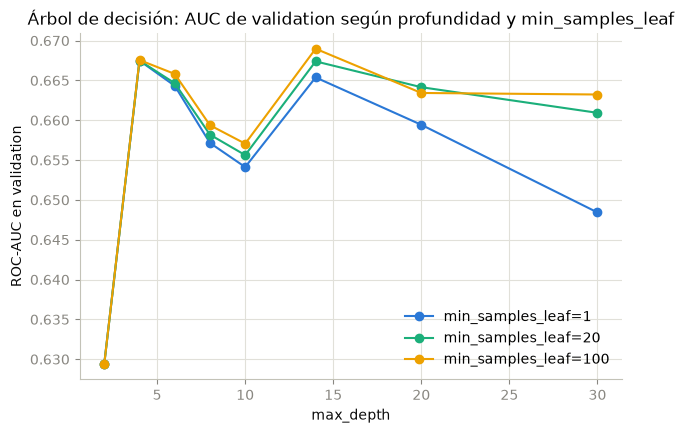


Mejor combinación: max_depth=14, min_samples_leaf=100 -> ROC-AUC validation=0.6690


In [7]:
max_depth_grid = [2, 4, 6, 8, 10, 14, 20, 30]
leaf_grid = [1, 20, 100]

resultados_arbol = {}
for leaf in leaf_grid:
    aucs = []
    for depth in max_depth_grid:
        pipe = build_tree_pipeline(mejor_feats, max_depth=depth, min_samples_leaf=leaf)
        pipe.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1]))
    resultados_arbol[leaf] = aucs
    print(f"min_samples_leaf={leaf:<4} | " + " | ".join(f"depth={d}: {a:.4f}" for d, a in zip(max_depth_grid, aucs)))

plt.figure(figsize=(7, 4.5))
for (leaf, aucs), color in zip(resultados_arbol.items(), [C_AZUL, C_AQUA, C_AMARILLO]):
    plt.plot(max_depth_grid, aucs, marker="o", color=color, label=f"min_samples_leaf={leaf}")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC en validation")
plt.title("Árbol de decisión: AUC de validation según profundidad y min_samples_leaf")
plt.legend(frameon=False)
plt.show()

mejor_leaf, mejor_depth, mejor_auc_arbol = None, None, -1.0
for leaf, aucs in resultados_arbol.items():
    i = int(np.argmax(aucs))
    if aucs[i] > mejor_auc_arbol:
        mejor_auc_arbol = aucs[i]
        mejor_depth = max_depth_grid[i]
        mejor_leaf = leaf

print(f"\nMejor combinación: max_depth={mejor_depth}, min_samples_leaf={mejor_leaf} -> ROC-AUC validation={mejor_auc_arbol:.4f}")

**Para interpretar el gráfico:** la curva no es la "U invertida" perfectamente suave del libro — sube fuerte de `max_depth=2` a `4`, después zigzaguea en el medio y recién en `max_depth=14` vuelve a acercarse al pico. Eso es real y vale la pena explicarlo con lo que dice la propia clase: un holdout único (nuestro caso, por el tamaño del dataset) es más ruidoso que promediar varios folds — el profesor lo dijo explícitamente sobre K-Fold vs. holdout. Elegimos holdout por el volumen de datos, y esto es el costo de esa decisión: una curva de validación con más zigzag del ideal. Lo que sí es nítido y consistente con la teoría es el rol de `min_samples_leaf` en el extremo: a `max_depth=30`, sin freno (`leaf=1`) el AUC se derrumba a 0.648, mientras que con `leaf=100` se sostiene en 0.663 — el freno contra el overfitting funciona como se explicó en clase. Nos quedamos con la combinación que **maximiza `validation`** (no `train`, que acá ni calculamos: el objetivo de esta grilla es puramente elegir hiperparámetros, no repetir el diagnóstico de over/underfitting que ya vimos con K en la Clase 1).

### Importancia de atributos del árbol elegido

La clase mostró cómo un árbol permite rankear variables: cada corte genera una "ganancia" (cuánto baja el Gini), y sumando las ganancias de todos los cortes que usan una variable se obtiene su importancia total. scikit-learn ya la calcula (`.feature_importances_`); la normalizamos a escala 0-100 (100 = la variable con más ganancia acumulada), igual que se mostró en clase.

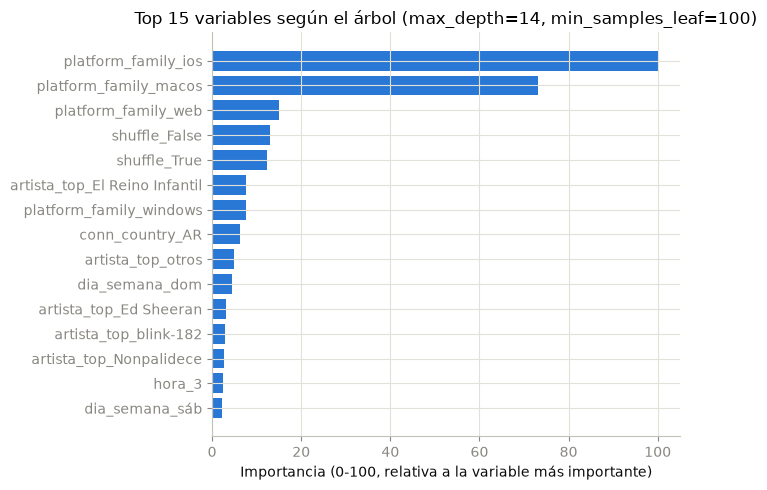

Columnas post one-hot usadas por el árbol: 83 de 124


In [8]:
best_tree_pipeline = build_tree_pipeline(mejor_feats, max_depth=mejor_depth, min_samples_leaf=mejor_leaf)
best_tree_pipeline.fit(X_tr, y_tr)

nombres_onehot = best_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
importancias = best_tree_pipeline.named_steps["tree"].feature_importances_

imp_df = pd.DataFrame({"feature": nombres_onehot, "importancia": importancias})
imp_df = imp_df[imp_df["importancia"] > 0].sort_values("importancia", ascending=False)
imp_df["importancia_norm"] = 100 * imp_df["importancia"] / imp_df["importancia"].max()

top_n = 15
top_imp = imp_df.head(top_n).iloc[::-1].copy()
top_imp["feature"] = top_imp["feature"].str.replace("onehot__", "", regex=False)

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["importancia_norm"], color=C_AZUL)
plt.xlabel("Importancia (0-100, relativa a la variable más importante)")
plt.title(f"Top {top_n} variables según el árbol (max_depth={mejor_depth}, min_samples_leaf={mejor_leaf})")
plt.tight_layout()
plt.show()

print(f"Columnas post one-hot usadas por el árbol: {len(imp_df)} de {len(nombres_onehot)}")

### Comparación final honesta: árbol vs. KNN, evaluados una única vez en `test_interno`

Ahora sí, el momento del test: lo tocamos **una sola vez**, con los dos modelos ya elegidos (no volvemos a tunear nada mirando este número). Es la única manera de responder "¿cuál de los dos es mejor?" sin el sesgo optimista de haber espiado el resultado muchas veces.

Para que sea una carrera justa, el campeón de KNN de la Clase 1 (features del conjunto C, K elegido por holdout) se **reconstruye dentro de esta misma partición cronológica**: la muestra de 100.000 filas para entrenarlo sale únicamente de `train` (nunca de `validation` ni de `test_interno` — si tomáramos la muestra del dataset completo, como en la Clase 1, se filtrarían filas del futuro hacia el entrenamiento) y el K se re-elige mirando `validation`. Así, árbol y KNN quedan ajustados y tuneados exactamente con las mismas reglas del juego.

Por costo computacional (KNN calcula distancia contra las 100.000 filas de su muestra por cada predicción) evaluamos a ambos modelos sobre una **submuestra estratificada de `test_interno`** de 30.000 filas — grande y aleatoria, así que sigue siendo una estimación confiable, pero factible en tiempo razonable. El árbol, que es barato de predecir, lo evaluamos además sobre el `test_interno` completo como chequeo de robustez.

Para reconstruir el campeón necesitamos el mismo pipeline de KNN de la Clase 1: one-hot encoding (la distancia euclídea no tiene sentido entre categorías) + escalado por desvío estándar sin centrar (`with_mean=False`, porque el output de `OneHotEncoder` es *sparse* y centrar lo volvería denso). El detalle completo de por qué escalar ayuda está en `tp_spotify_clase1_knn.ipynb`.

In [9]:
def build_knn_pipeline(k, features):
    preprocessor = ColumnTransformer(
        transformers=[
            ("onehot", OneHotEncoder(handle_unknown="ignore"), features),
        ],
        remainder="drop",
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("scaler", StandardScaler(with_mean=False)),
            ("knn", KNeighborsClassifier(n_neighbors=k)),
        ]
    )

In [10]:
# --- Reconstruir el campeón de KNN dentro de este esquema (sin fuga de validation/test_interno) ---
KNN_SAMPLE_SIZE = 100_000

knn_sample, _ = train_test_split(
    df_train,
    train_size=KNN_SAMPLE_SIZE,
    stratify=df_train["target"],
    random_state=RANDOM_STATE,
)
X_knn_train, y_knn_train = build_xy(knn_sample)

# Submuestra de validation para elegir K (mismo motivo que en la Clase 1: predecir sobre validation entero sería lento)
val_sample_knn, _ = train_test_split(
    df_val, train_size=20_000, stratify=df_val["target"], random_state=RANDOM_STATE,
)
X_val_knn, y_val_knn = build_xy(val_sample_knn)

# 101 fue el campeón de la Clase 1 (holdout aleatorio, muestra de 20k); probamos también valores más grandes,
# porque acá la muestra de entrenamiento es 5x más grande.
candidatos_k = [101, 701, 1501]
mejor_k_final, mejor_auc_knn_val = None, -1.0
for k in candidatos_k:
    pipe = build_knn_pipeline(k, mejor_feats)
    pipe.fit(X_knn_train, y_knn_train)
    auc = roc_auc_score(y_val_knn, pipe.predict_proba(X_val_knn)[:, 1])
    print(f"K={k:>5} | ROC-AUC validation (KNN) = {auc:.4f}")
    if auc > mejor_auc_knn_val:
        mejor_k_final, mejor_auc_knn_val = k, auc

print("\nK elegido para el campeón de KNN:", mejor_k_final)

knn_champion = build_knn_pipeline(mejor_k_final, mejor_feats)
knn_champion.fit(X_knn_train, y_knn_train);

K=  101 | ROC-AUC validation (KNN) = 0.6422
K=  701 | ROC-AUC validation (KNN) = 0.6430
K= 1501 | ROC-AUC validation (KNN) = 0.6448

K elegido para el campeón de KNN: 1501


In [11]:
# --- Comparación final: una única mirada a test_interno ---
test_sample, _ = train_test_split(
    df_test_interno, train_size=30_000, stratify=df_test_interno["target"], random_state=RANDOM_STATE,
)
X_test_cmp, y_test_cmp = build_xy(test_sample)

auc_knn_test = roc_auc_score(y_test_cmp, knn_champion.predict_proba(X_test_cmp)[:, 1])
auc_tree_test = roc_auc_score(y_test_cmp, best_tree_pipeline.predict_proba(X_test_cmp)[:, 1])
auc_tree_test_full = roc_auc_score(y_te, best_tree_pipeline.predict_proba(X_te)[:, 1])

print("=== ROC-AUC en test_interno (tocado una única vez) ===")
print(f"KNN   (K={mejor_k_final}, muestra 100k de train)                         : {auc_knn_test:.4f}")
print(f"Árbol (max_depth={mejor_depth}, min_samples_leaf={mejor_leaf}, train completo): {auc_tree_test:.4f}")
print(f"\nÁrbol evaluado sobre TODO test_interno ({len(df_test_interno)} filas, chequeo de robustez): {auc_tree_test_full:.4f}")

ganador = "Árbol de decisión" if auc_tree_test > auc_knn_test else "KNN"
print(f"\nGanador en test_interno: {ganador}")

=== ROC-AUC en test_interno (tocado una única vez) ===
KNN   (K=1501, muestra 100k de train)                         : 0.6307
Árbol (max_depth=14, min_samples_leaf=100, train completo): 0.6420

Árbol evaluado sobre TODO test_interno (136703 filas, chequeo de robustez): 0.6394

Ganador en test_interno: Árbol de decisión


### Modelo final: reentrenar con el 100% de los datos y submission

Con la receta ya elegida y validada (features, `max_depth`, `min_samples_leaf`) y ya sabiendo honestamente qué tan bien predice en `test_interno`, seguimos la misma práctica que en la Clase 1: el modelo que va a Kaggle se reentrena con el **100% de las filas de train** — ya no hace falta reservar nada, la validación cumplió su rol — porque más datos solo puede ayudar, y un árbol, a diferencia de KNN, entrena rápido incluso con el dataset completo.

In [12]:
final_tree_pipeline = build_tree_pipeline(mejor_feats, max_depth=mejor_depth, min_samples_leaf=mejor_leaf)
final_tree_pipeline.fit(*build_xy(train_raw, mejor_feats))

# Cargar el test de la competencia y aplicar las mismas derivaciones que en train
# (mismo TOP_ARTISTAS aprendido solo de train, para no filtrar información del test)
test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES,
)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
ts_test = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = ts_test.dt.hour
test_raw["dia_semana"] = ts_test.dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(
    test_raw[col_artista].isin(TOP_ARTISTAS), "otros"
)

X_test_kaggle = test_raw[mejor_feats].fillna("missing").astype(str)
test_pred_proba_tree = final_tree_pipeline.predict_proba(X_test_kaggle)[:, 1]

submission_tree = pd.DataFrame({
    "obs_id": test_raw["obs_id"],
    "target": test_pred_proba_tree,
})
submission_tree.to_csv("submission_clase2_arbol.csv", index=False)
print("Guardado submission_clase2_arbol.csv —", len(submission_tree), "filas")
submission_tree.head()

Guardado submission_clase2_arbol.csv — 51570 filas


,obs_id,target
0,911345,0.143804
1,911346,0.161362
2,911347,0.084922
3,911348,0.084922
4,911349,0.084922


### Notas honestas para el informe — Clase 2 (borrador, ir completando)

- **Qué se agregó respecto de la Clase 1:** esquema de validación formal train/validation/test (70/15/15, cronológico, sin mezclar épocas) sobre el dataset completo — reemplaza el holdout único + chequeo improvisado de la Clase 1. Nuevo algoritmo: árbol de decisión (`DecisionTreeClassifier`), pipeline más simple que KNN (sin escalado — los árboles no lo necesitan). Barrido de `max_depth` × `min_samples_leaf` contra `validation`. Importancia de atributos del árbol ganador. Comparación final honesta contra el campeón de KNN, ambos evaluados una única vez en `test_interno`.
- **Por qué train/validation/test y no K-Fold:** el profesor fue explícito en que con datasets de cientos de miles de filas (nuestro caso) el K-Fold es cómputo de más sin beneficio real; alcanza con holdout. Y como probamos muchas combinaciones (grilla del árbol + comparación de dos algoritmos), separar un test que se toca una sola vez evita el sesgo optimista de "overfitting the validation set".
- **Resultado de la comparación honesta (test_interno, submuestra de 30k, tocado una única vez):** árbol (`max_depth=14`, `min_samples_leaf=100`, entrenado con el 100% de `train`) AUC=**0.6420** vs. KNN (K=1501, muestra de 100k) AUC=**0.6307**. Gana el árbol por ~1.1 puntos de AUC. Chequeo de robustez: el árbol evaluado sobre el `test_interno` completo (136.703 filas, no solo la submuestra) da AUC=0.6394 — consistente con el número de arriba, así que la comparación no es un artefacto de la submuestra elegida.
- **Limitaciones conocidas, para seguir después:** no se re-corrió la comparación de conjuntos de features (A/B/C) para el árbol — se reusó directamente el ganador de KNN (conjunto C), que podría no ser el óptimo para un árbol. Tampoco se tuneó `min_samples_split` (se dejó el default de scikit-learn). La curva de validación del árbol salió más ruidosa de lo ideal (ver nota junto al gráfico) — esperable con un holdout único en vez de K-Fold, tradeoff que tomamos a propósito por el tamaño del dataset. `spotify_api_data` y las variables de alta cardinalidad sin agrupar siguen sin explorarse.
- **Experimento post-cierre — `user_id`: probado y rechazado.** Con `user_id`, el mejor AUC en validation cae a 0.6478 (vs. 0.6690 sin ella); con más profundidad se derrumba hasta 0.585. Causa verificada: tasas de abandono por usuario inestables entre épocas (el caso extremo pasa de 8% de abandono en train a 44% en validation, cuadruplicando su actividad). Un split aleatorio habría aprobado la feature falsamente; el cronológico la rechazó — evidencia de que el esquema de validación funciona. Detalle y números en la sección final del notebook.
- **Ronda de mejoras dentro del temario (sección final):** hora numérica, poda por α (`min_impurity_decrease`) y tamaño del top de artistas — cada una con hipótesis mecánica explícita y validada por separado contra `validation`, con adopción secuencial. Completar acá el veredicto cuando la ronda cierre.
- **Submissions:** `submission_clase2_arbol.csv`, generado con el 100% del train y la receta elegida por validación. Falta subirlo a Kaggle y anotar el score público acá.
- **Próximos pasos naturales:** el profesor adelantó que XGBoost es "el modelo que van a usar en el TP" — los árboles de esta clase son la base conceptual para eso.

## Mejora dentro del temario (Clases 1–2): revisar la exclusión de `user_id`

Con la Clase 2 cerrada, repasamos qué herramienta ya vista quedó sin explotar. La mejora más fuerte disponible no es una técnica nueva: es una **decisión de la Clase 1 que la Clase 2 da argumentos para revisar**. En la Clase 1 excluimos `user_id` por ser "identificador, no una característica generalizable". Revisado contra los datos crudos y contra lo que dice la clase, ese argumento no se sostiene acá:

- **El problema de los identificadores es la cardinalidad, no el nombre.** La clase lo mostró con el ejemplo del DNI: una variable con tantas categorías como filas permite una rama por observación → overfitting perfecto e inservible. `user_id` es exactamente lo contrario: **10 valores para 911.344 filas** (~90.000 observaciones por usuario; verificado sobre los archivos). La tasa de abandono de cada usuario se estima con decenas de miles de casos — es una categórica de cardinalidad bajísima, con menos categorías que `artista_top`.
- **Generaliza exactamente a donde se va a usar el modelo.** El esquema *leave-one-group-out* de la clase aplica cuando se quiere predecir en un grupo nuevo (la "provincia donde la empresa todavía no está"). No es nuestro caso: **los 10 usuarios del test de Kaggle son los mismos 10 del train** (verificado). El modelo va a predecir para las mismas personas, más adelante en el tiempo — y nuestro split cronológico replica exactamente ese escenario, que es el criterio de la clase: que validación replique el uso real.
- **El árbol es el modelo ideal para esta variable.** Cada hoja predice la proporción de clases de su región: un corte por usuario le da a cada uno su propia tasa base de abandono, y los cortes anidados captan interacciones usuario × hora, usuario × artista — la clase destacó que los árboles "captan interacciones de manera automática".

Protocolo de siempre, el que la clase usó para "¿escalar sí o no?": **una decisión nueva, un número que la valida**. Se re-corre la misma grilla contra `validation` con el único cambio de agregar `user_id`, y se compara contra el mejor árbol sin ella. `test_interno` no se toca en este experimento.

In [13]:
# Diagnóstico previo, solo con train (validation/test_interno no se miran para esto):
# si la tasa de abandono varía mucho entre usuarios, la variable trae señal real.
diag_usuarios = (
    df_train.groupby("user_id")["target"]
    .agg(filas="size", tasa_abandono="mean")
    .sort_values("tasa_abandono", ascending=False)
)
print(f"Usuarios distintos en train: {len(diag_usuarios)} | tasa global de train: {df_train['target'].mean():.4f}")
diag_usuarios.round(4)

Usuarios distintos en train: 10 | tasa global de train: 0.2864


,filas,tasa_abandono
user_id,,
607e9350fb5a26619dbe8c98c365fefbb1ca118fb6f43ef400d0ca381de5aa34,1,1.0000
11ce99f6dfdbdeb01412471d46993e4a707c2b3d5e6eaedaf734fb4c39ac6473,100421,0.5603
eb975aec35e98925ded94e6e978a3fad6d1c06753c2184c438ceadb5e1e9fc12,46836,0.4605
54971d5ef686772751635cfbca7cef7abc2db839df50151ba9fb45590b37898e,99530,0.3985
a5260fbfb7b2be30fc12bff12c239bbe222a16172e6fb996fe2d448375bae439,56751,0.2643
c905c2404d23b7d8045df9cf8fe53501df8fb1f0aa175b4e8a1da4a784daaffd,51186,0.2468
6c4d27bcd20d8761de4668d221110c98b4030dca1787a201f427b205083fa799,38287,0.2085
18f72490eac4fa92741faf45964a9135301dbd0b74094548d62ff589c1ee9f00,67368,0.1546
3175a05fd828cb5c38584fc33fc95e013cd953e1adf8f69d312fc0ac85a408a9,152929,0.1122


min_samples_leaf=1    | depth=2: 0.6349 | depth=4: 0.6478 | depth=6: 0.6164 | depth=8: 0.6222 | depth=10: 0.6209 | depth=14: 0.5996 | depth=20: 0.5914 | depth=30: 0.5851
min_samples_leaf=20   | depth=2: 0.6349 | depth=4: 0.6478 | depth=6: 0.6164 | depth=8: 0.6250 | depth=10: 0.6159 | depth=14: 0.6050 | depth=20: 0.5996 | depth=30: 0.6055
min_samples_leaf=100  | depth=2: 0.6349 | depth=4: 0.6478 | depth=6: 0.6217 | depth=8: 0.6300 | depth=10: 0.6249 | depth=14: 0.6146 | depth=20: 0.6206 | depth=30: 0.6250


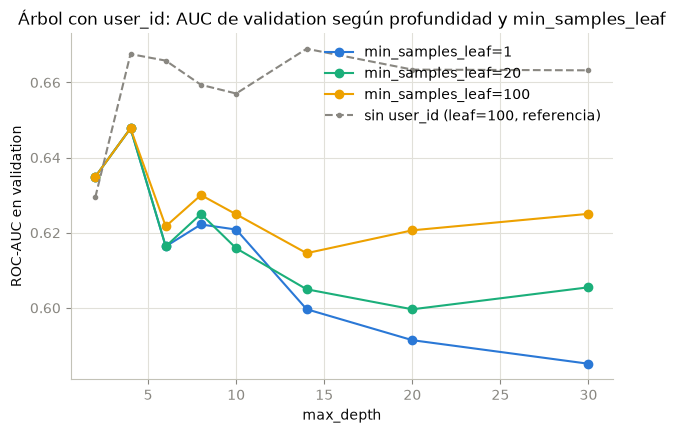


Sin user_id: max_depth=14, min_samples_leaf=100 -> ROC-AUC validation 0.6690
Con user_id: max_depth=4, min_samples_leaf=1 -> ROC-AUC validation 0.6478
Diferencia: -0.0212


In [14]:
# Misma grilla que antes; la única decisión nueva es la feature user_id.
FEATURES_V2 = TODAS_LAS_FEATURES + ["user_id"]

X_tr_v2, _ = build_xy(df_train, FEATURES_V2)
X_val_v2, _ = build_xy(df_val, FEATURES_V2)

resultados_arbol_v2 = {}
for leaf in leaf_grid:
    aucs = []
    for depth in max_depth_grid:
        pipe = build_tree_pipeline(FEATURES_V2, max_depth=depth, min_samples_leaf=leaf)
        pipe.fit(X_tr_v2, y_tr)
        aucs.append(roc_auc_score(y_val, pipe.predict_proba(X_val_v2)[:, 1]))
    resultados_arbol_v2[leaf] = aucs
    print(f"min_samples_leaf={leaf:<4} | " + " | ".join(f"depth={d}: {a:.4f}" for d, a in zip(max_depth_grid, aucs)))

plt.figure(figsize=(7, 4.5))
for (leaf, aucs), color in zip(resultados_arbol_v2.items(), [C_AZUL, C_AQUA, C_AMARILLO]):
    plt.plot(max_depth_grid, aucs, marker="o", color=color, label=f"min_samples_leaf={leaf}")
plt.plot(max_depth_grid, resultados_arbol[mejor_leaf], marker=".", linestyle="--", color=C_MUTED,
         label=f"sin user_id (leaf={mejor_leaf}, referencia)")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC en validation")
plt.title("Árbol con user_id: AUC de validation según profundidad y min_samples_leaf")
plt.legend(frameon=False)
plt.show()

mejor_leaf_v2, mejor_depth_v2, mejor_auc_arbol_v2 = None, None, -1.0
for leaf, aucs in resultados_arbol_v2.items():
    i = int(np.argmax(aucs))
    if aucs[i] > mejor_auc_arbol_v2:
        mejor_auc_arbol_v2 = aucs[i]
        mejor_depth_v2 = max_depth_grid[i]
        mejor_leaf_v2 = leaf

print(f"\nSin user_id: max_depth={mejor_depth}, min_samples_leaf={mejor_leaf} -> ROC-AUC validation {mejor_auc_arbol:.4f}")
print(f"Con user_id: max_depth={mejor_depth_v2}, min_samples_leaf={mejor_leaf_v2} -> ROC-AUC validation {mejor_auc_arbol_v2:.4f}")
print(f"Diferencia: {mejor_auc_arbol_v2 - mejor_auc_arbol:+.4f}")

### Veredicto del experimento `user_id`: RECHAZADA (y por qué es un buen resultado)

- Mejor árbol **con** `user_id`: AUC validation **0.6478** (y con `max_depth=4`; a más profundidad se derrumba hasta 0.585). **Sin** ella: **0.6690**. La feature resta ~2.1 puntos.
- Causa, verificada aparte comparando tasas por usuario entre el período de train y el de validation: **las tasas por usuario no son estables en el tiempo**. El caso extremo pasa de 8.3% de abandono en train a 44.5% en validation, y cuadruplica su share de filas (3.9% → 14.6%); otros dos usuarios grandes se mueven ±16 puntos. El árbol, que construye de forma golosa, elige primero esos cortes (ganancia enorme *en train*) y desplaza a las features estables — por eso empeora incluso con poca profundidad.
- Moraleja para el informe: con un split **aleatorio** esta feature habría mostrado una mejora grande y falsa (mezclar épocas hace que las tasas por usuario "transfieran" de train a validation). El esquema cronológico hizo exactamente el trabajo para el que se construyó. Un resultado negativo documentado es *feature engineering probado y justificado* — textual de la consigna.

La receta de la Clase 2 sigue vigente (`submission_clase2_arbol.csv`). Abajo continúa la ronda de mejoras dentro del temario.